In [1]:
# import cartopy.crs as ccrs
# import cartopy.feature as cfeature
import sys
from pathlib import Path
from string import ascii_lowercase, ascii_uppercase

import matplotlib as mpl
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr
from IPython.display import HTML, Image, display
from scipy import stats

/hpx/Data_impb/kales/conda/envs/myenv/lib/python3.11/site-packages/scikits/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  __import__("pkg_resources").declare_namespace(__name__)


In [2]:
xr.set_options(keep_attrs=True)
rootpath = Path("/sto0/data/Intermediate/Hunga_Tonga_byAles/")
infile_path =rootpath / "ht"
plt.rcParams.update({"font.size": 22})

In [3]:
def open_lw_dataset(inpath):
    ds = xr.open_dataset(inpath)
    ds["pressure"] = ds.pressure.values / 100.0
    ds["pressure"].attrs["units"] = "hPa"
    ds = ds.where(ds.time >= 0, drop = True)
    ds['time'] = pd.to_datetime(ds.time, unit='s', origin='unix') 
    return ds

In [4]:
inpath = rootpath / 'alistair' / 'lw_rt_sim_ens_0_9_2023_2024.nc'#'lw_rt_sim_ens_0 1.nc'
ds_lw = open_lw_dataset(inpath)

In [5]:
inpath = rootpath / 'alistair' / 'lw_output_no_Temperature_change.nc'#'lw_rt_sim_ens_0 1.nc'
ds_lw2 = open_lw_dataset(inpath) 

In [6]:
inpath = rootpath / 'alistair' / 'ales_lw_output_no_Temperature_change_no_ozone_change.nc'#'lw_rt_sim_ens_0 1.nc'
ds_lw3 = open_lw_dataset(inpath)

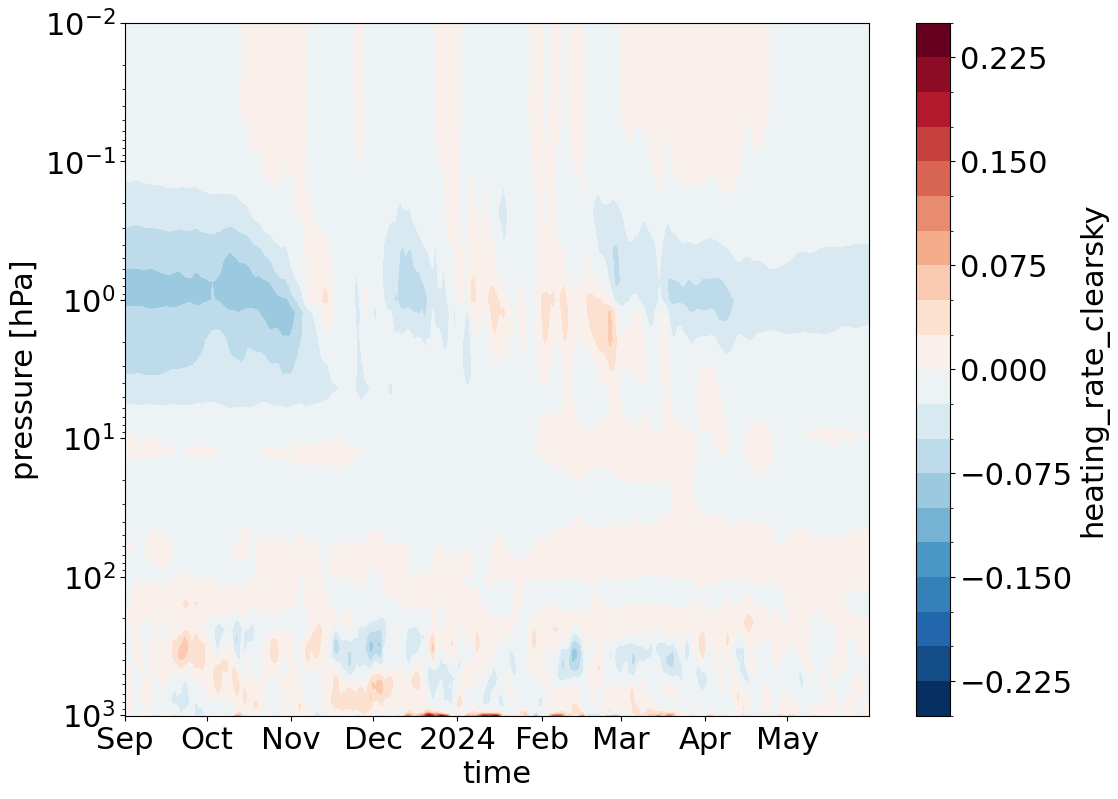

In [7]:
weights = np.cos(np.deg2rad(ds_lw.lat))
weights.name = "weights"
diff_lw = ds_lw2['heating_rate_clearsky'].weighted(weights).mean(['lat','ens']).sel(experiment = 'with')-ds_lw2['heating_rate_clearsky'].weighted(weights).mean(['lat','ens']).sel(experiment = 'without')
diff_lw.plot.contourf(yincrease = False, x = 'time', size = 9, levels = 21, vmax = 0.25)
plt.yscale('log')

In [8]:
def process_daily(ds, deseasonalize=False):
    ds = ds.drop_vars(["var152", "time_bnds", "lat_bnds"], errors="ignore")
    time_arr = ds.time.values
    ds['time'] = pd.to_datetime(np.floor(time_arr), format = '%Y%m%d')
    #ds["time"] = pd.date_range("2021-01", freq="D", periods=ds.time.shape[0])
    ds["plev"] = ds.plev.values / 100.0
    ds["plev"].attrs["units"] = "hPa"
    ds["plev"].attrs["long_name"] = "pressure"
    ds["plev"].attrs["standard_name"] = "pressure"

    if deseasonalize:
        ds = anomalize_func(ds)  # deseasonalize_func(ds)

    return ds.sel(plev=slice(0.1, 100))

In [9]:
what = "H2O_m"
infiles_w = list(infile_path.glob(f"socol4_htt1*{what}*daily.nc"))
infiles_wo = list(infile_path.glob(f"socol4_htt2*{what}*daily.nc"))

In [10]:
time_arr = xr.open_mfdataset(
    infiles_w,
    parallel=True,  #  will be performed in parallel using dask.delayed
    combine="nested",
    concat_dim=["ens"],
    # chunks = dict(plev = 1, time = 365)
)['time'].values
 

In [11]:
ds_w_wv = xr.open_mfdataset(
    infiles_w,
    parallel=True,  #  will be performed in parallel using dask.delayed
    combine="nested",
    concat_dim=["ens"],
    # chunks = dict(plev = 1, time = 365)
).pipe(
    process_daily, deseasonalize=False
)  # .chunk(plev = 1, time = 365)
# ds_w_wv["ens"] = ens_name_ls
ds_w_wv

<xarray.Dataset> Size: 28GB
Dimensions:  (ens: 10, time: 1826, plev: 21, lat: 96, lon: 192)
Coordinates:
  * time     (time) datetime64[ns] 15kB 2021-01-01 2021-01-02 ... 2025-12-31
  * lon      (lon) float64 2kB 0.0 1.875 3.75 5.625 ... 352.5 354.4 356.2 358.1
  * lat      (lat) float64 768B 88.57 86.72 84.86 83.0 ... -84.86 -86.72 -88.57
  * plev     (plev) float64 168B 0.1112 0.2315 0.4259 ... 74.06 91.02 100.0
Dimensions without coordinates: ens
Data variables:
    H2O_m    (ens, time, plev, lat, lon) float32 28GB dask.array<chunksize=(1, 1826, 21, 96, 192), meta=np.ndarray>
Attributes:
    CDI:          Climate Data Interface version 1.9.10 (https://mpimet.mpg.d...
    Conventions:  CF-1.6
    history:      Mon Feb 26 14:43:50 2024: cdo cat rr3.nc /scratch/snx3000/a...
    CDO:          Climate Data Operators version 1.9.10 (https://mpimet.mpg.d...

In [13]:
ds_wo_wv = xr.open_mfdataset(
    infiles_wo,
    parallel=True,  #  will be performed in parallel using dask.delayed
    combine="nested",
    concat_dim=["ens"],
    # chunks = dict(plev = 1, time = 365)
).pipe(process_daily, deseasonalize=False)
ds_wo_wv

<xarray.Dataset> Size: 28GB
Dimensions:  (ens: 10, time: 1826, plev: 21, lat: 96, lon: 192)
Coordinates:
  * time     (time) datetime64[ns] 15kB 2021-01-01 2021-01-02 ... 2025-12-31
  * lon      (lon) float64 2kB 0.0 1.875 3.75 5.625 ... 352.5 354.4 356.2 358.1
  * lat      (lat) float64 768B 88.57 86.72 84.86 83.0 ... -84.86 -86.72 -88.57
  * plev     (plev) float64 168B 0.1112 0.2315 0.4259 ... 74.06 91.02 100.0
Dimensions without coordinates: ens
Data variables:
    H2O_m    (ens, time, plev, lat, lon) float32 28GB dask.array<chunksize=(1, 1461, 21, 96, 192), meta=np.ndarray>
Attributes:
    CDI:          Climate Data Interface version 1.9.10 (https://mpimet.mpg.d...
    Conventions:  CF-1.6
    history:      Mon Feb 26 16:11:55 2024: cdo cat rr3.nc /scratch/snx3000/a...
    CDO:          Climate Data Operators version 1.9.10 (https://mpimet.mpg.d...

In [14]:
dims4ave = ['lon']
sel_dict = dict(lat = slice(None,60), time = slice("2023-09", "2024-04"))
arr1 = ds_w_wv['H2O_m'].mean(dims4ave).sel(**sel_dict)
weights = np.cos(np.deg2rad(arr1.lat))
weights.name = "weights"
arr1 = arr1.weighted(weights).mean('lat').load()*1e6
arr2 = ds_wo_wv['H2O_m'].mean(dims4ave).sel(**sel_dict).weighted(weights).mean('lat').load()*1e6
#diff = arr1 - arr2
diff_sel_pcap = arr1.mean('ens') - arr2.mean('ens')
diff_sel_pcap.attrs['units'] = 'ppmv'
#diff_sel_pcap.attrs['long_name'] = 'temperature'

t_stat, p_values = stats.ttest_ind(
    arr1, arr2, equal_var=False
)  # , nan_policy = nan_policy)
diff_sel_pcap_pv = xr.DataArray(p_values, coords=diff_sel_pcap.coords)

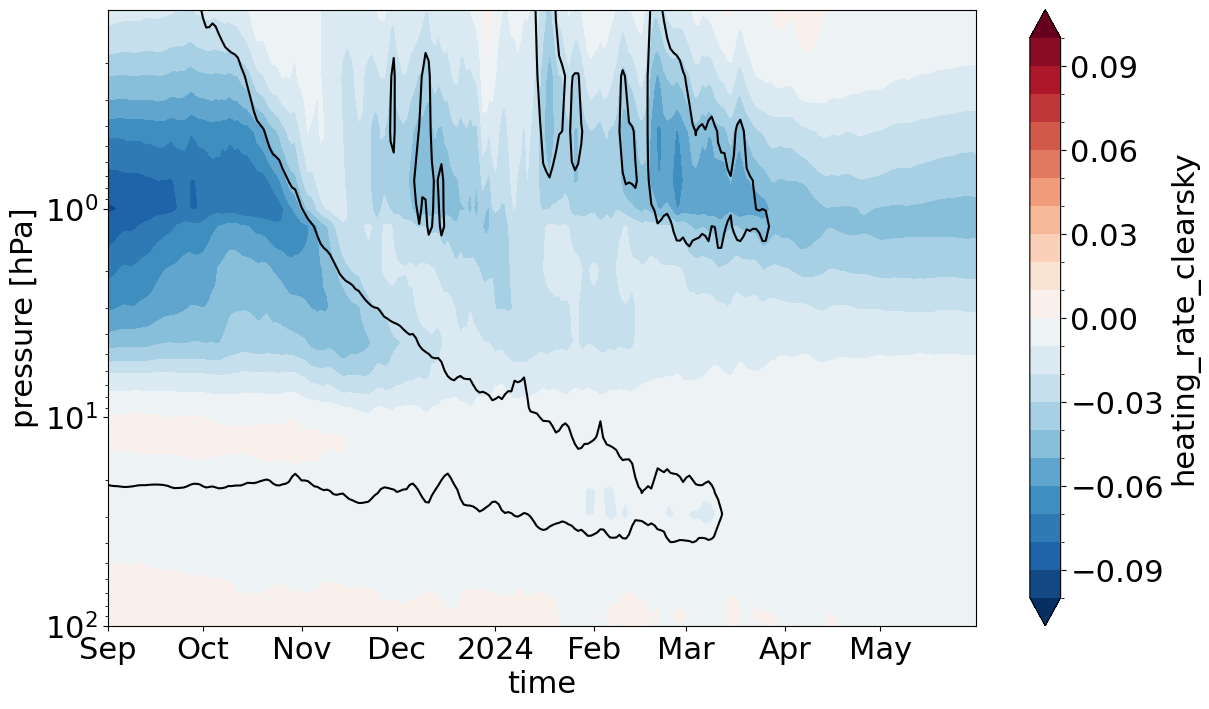

In [83]:
f, ax = plt.subplots(1, 1, figsize=(14, 8), sharex=True)


weights = np.cos(np.deg2rad(ds_lw.lat))
weights.name = "weights"

ds_lw_sel = ds_lw3.sel(pressure = slice(100,0.09))
arr1 = ds_lw_sel['heating_rate_clearsky'].weighted(weights).mean(['lat']).sel(experiment = 'with')
arr2 = ds_lw_sel['heating_rate_clearsky'].weighted(weights).mean(['lat']).sel(experiment = 'without')
t_stat, p_values = stats.ttest_ind(
    arr1, arr2, equal_var=False
)  # , nan_policy = nan_policy)
diff_sel_pcap_pv = xr.DataArray(p_values, coords=arr1[0].coords)

diff_lw = arr1.mean('ens')-arr2.mean('ens')
p = diff_lw.plot.contourf(yincrease = False, x = 'time', levels = np.arange(-0.1,0.11,0.01), ax = ax, add_colorbar = True, extend = 'both')
p_ls.append(p)

(diff_sel_pcap).plot.contour(
    x = 'time', ax = ax, yincrease = False, 
    levels = [0.5], colors = ['k'],
)
ax.set_yscale('log')

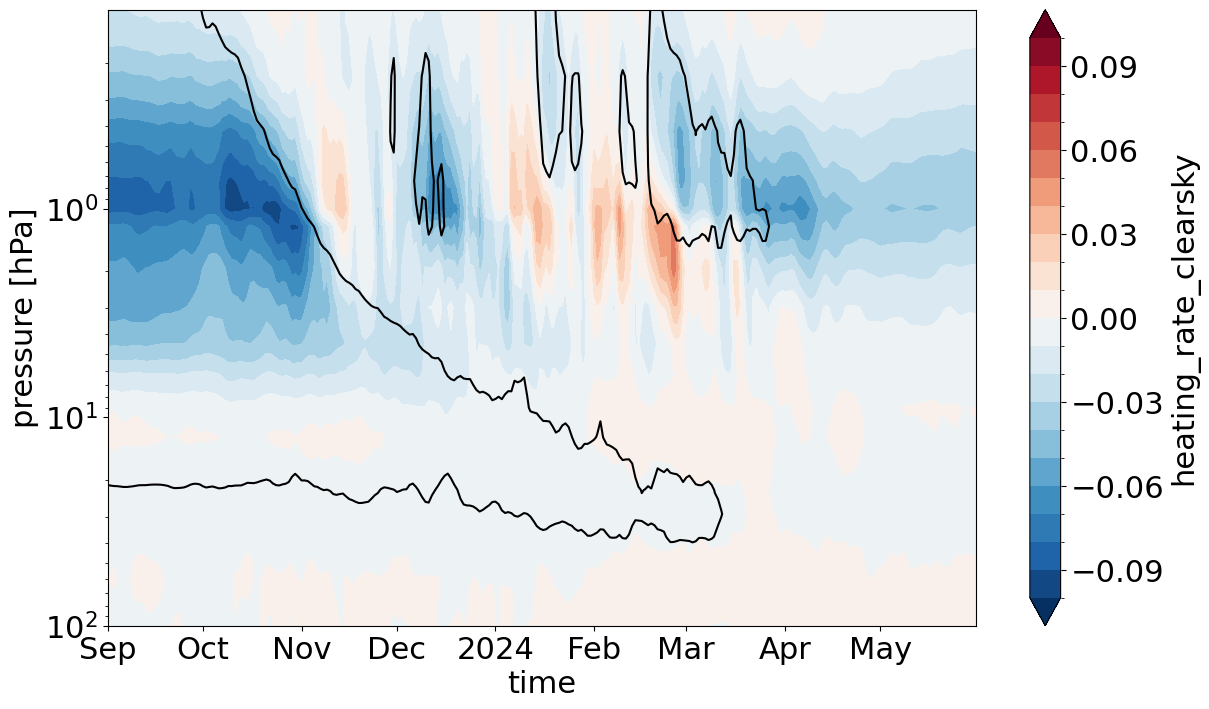

In [87]:
f, ax = plt.subplots(1, 1, figsize=(14, 8), sharex=True)


weights = np.cos(np.deg2rad(ds_lw.lat))
weights.name = "weights"

ds_lw_sel = ds_lw2.sel(pressure = slice(100,0.09))
arr1 = ds_lw_sel['heating_rate_clearsky'].weighted(weights).mean(['lat']).sel(experiment = 'with')
arr2 = ds_lw_sel['heating_rate_clearsky'].weighted(weights).mean(['lat']).sel(experiment = 'without')
t_stat, p_values = stats.ttest_ind(
    arr1, arr2, equal_var=False
)  # , nan_policy = nan_policy)
diff_sel_pcap_pv = xr.DataArray(p_values, coords=arr1[0].coords)

diff_lw = arr1.mean('ens')-arr2.mean('ens')
p = diff_lw.plot.contourf(yincrease = False, x = 'time', levels = np.arange(-0.1,0.11,0.01), ax = ax, add_colorbar = True, extend = 'both')
p_ls.append(p)

(diff_sel_pcap).plot.contour(
    x = 'time', ax = ax, yincrease = False, 
    levels = [0.5], colors = ['k'],
)
ax.set_yscale('log')

In [89]:
diff_lw.min()

<xarray.DataArray 'heating_rate_clearsky' ()> Size: 4B
array(-0.09725666, dtype=float32)

In [86]:
diff_lw.min()

<xarray.DataArray 'heating_rate_clearsky' ()> Size: 4B
array(-0.09142685, dtype=float32)

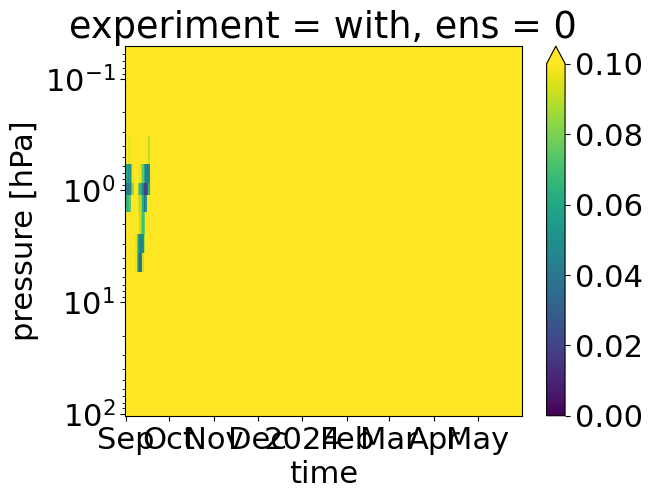

In [75]:
diff_sel_pcap_pv.plot(yincrease = False, x ='time', vmax = 0.1, vmin = 0)
plt.yscale('log')

/tmp/ipykernel_829423/2303674591.py:156: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(pad=0.4, w_pad=0.5, h_pad=.5)


HR+WV_time-evolution_2023-2024.pdf


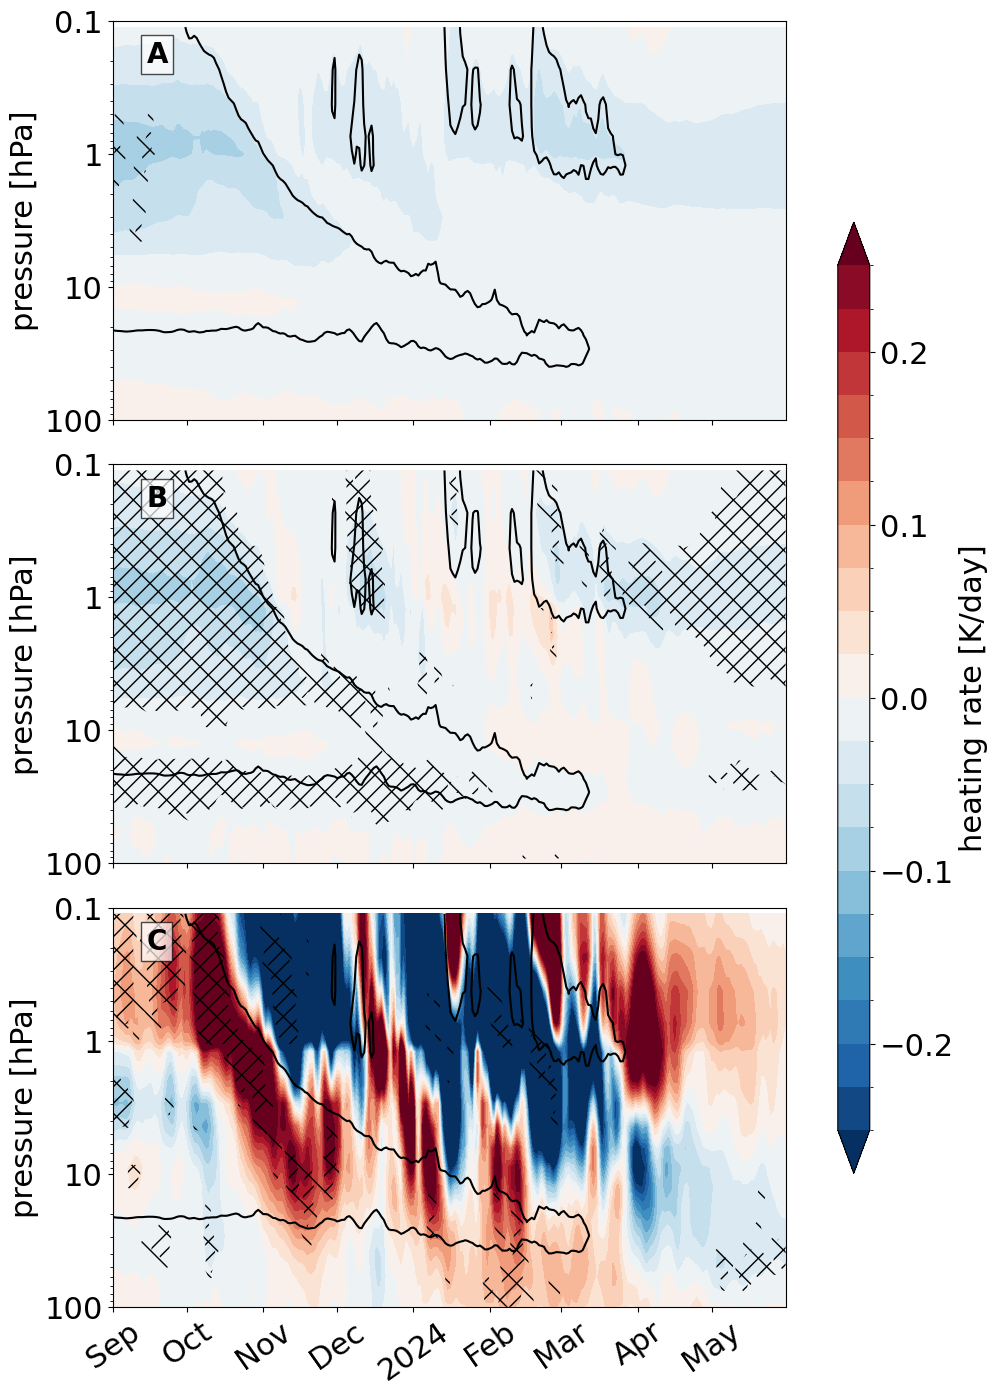

In [81]:
f, axes = plt.subplots(3, 1, figsize=(8, 14), sharex=True)
p_ls = []


weights = np.cos(np.deg2rad(ds_lw.lat))
weights.name = "weights"

ax = axes[0]
ds_lw_sel = ds_lw3.sel(pressure = slice(100,0.09))
arr1 = ds_lw_sel['heating_rate_clearsky'].weighted(weights).mean(['lat']).sel(experiment = 'with')
arr2 = ds_lw_sel['heating_rate_clearsky'].weighted(weights).mean(['lat']).sel(experiment = 'without')
t_stat, p_values = stats.ttest_ind(
    arr1, arr2, equal_var=False
)  # , nan_policy = nan_policy)
diff_sel_pcap_pv = xr.DataArray(p_values, coords=arr1[0].coords)
diff_lw = arr1.mean('ens')-arr2.mean('ens')
p = diff_lw.plot.contourf(yincrease = False, x = 'time', levels = 21, vmax = 0.25, ax = ax, add_colorbar = False, extend = 'both')
p_ls.append(p)

(diff_sel_pcap).plot.contour(
    x = 'time', ax = ax, yincrease = False, 
    levels = [0.5], colors = ['k'],
)


kwargs = dict(
    yincrease= False,
    # colors=("k"),
    add_colorbar=False,
    levels=[0, 0.05],
    colors="none",
    hatches=[
        "//",
        None,
    ],
    ax=ax,
    # linewidths=np.linspace(1, 4, 4),
)

diff_sel_pcap_pv.squeeze().plot.contourf(x="time", **kwargs)
kwargs['levels'] = [0,0.1]
kwargs['hatches'] = ["\\",  None]
diff_sel_pcap_pv.squeeze().plot.contourf(x="time", **kwargs)

ax.set_xlabel('')

ax =axes[2]
ds_lw_sel = ds_lw.sel(pressure = slice(100,0.09))
arr1 = ds_lw_sel['heating_rate_clearsky'].weighted(weights).mean(['lat']).sel(experiment = 'with')
arr2 = ds_lw_sel['heating_rate_clearsky'].weighted(weights).mean(['lat']).sel(experiment = 'without')
t_stat, p_values = stats.ttest_ind(
    arr1, arr2, equal_var=False
)  # , nan_policy = nan_policy)
diff_sel_pcap_pv = xr.DataArray(p_values, coords=arr1[0].coords)
diff_lw = arr1.mean('ens')-arr2.mean('ens')
p = diff_lw.plot.contourf(yincrease = False, x = 'time', levels = 21, vmax = 0.25, ax = ax, add_colorbar = False, extend = 'both')
p_ls.append(p)

(diff_sel_pcap).plot.contour(
    x = 'time', ax = ax, yincrease = False, 
    levels = [0.5], colors = ['k'],
)

kwargs = dict(
    yincrease= False,
    # colors=("k"),
    add_colorbar=False,
    levels=[0, 0.05],
    colors="none",
    hatches=[
        "//",
        None,
    ],
    ax=ax,
    # linewidths=np.linspace(1, 4, 4),
)

diff_sel_pcap_pv.squeeze().plot.contourf(x="time", **kwargs)
kwargs['levels'] = [0,0.1]
kwargs['hatches'] = ["\\",  None]
diff_sel_pcap_pv.squeeze().plot.contourf(x="time", **kwargs)

ax.set_xlabel('')

ax =axes[1]
ds_lw_sel = ds_lw2.sel(pressure = slice(100,0.09))
arr1 = ds_lw_sel['heating_rate_clearsky'].weighted(weights).mean(['lat']).sel(experiment = 'with')
arr2 = ds_lw_sel['heating_rate_clearsky'].weighted(weights).mean(['lat']).sel(experiment = 'without')
t_stat, p_values = stats.ttest_ind(
    arr1, arr2, equal_var=False
)  # , nan_policy = nan_policy)
diff_sel_pcap_pv = xr.DataArray(p_values, coords=arr1[0].coords)

diff_lw = arr1.mean('ens')-arr2.mean('ens')
p2 = diff_lw.plot.contourf(yincrease = False, x = 'time', levels = 21, vmax = 0.25, ax = ax, add_colorbar = False, extend = 'both')
p_ls.append(p2)

(diff_sel_pcap).plot.contour(
    x = 'time', ax = ax, yincrease = False, 
    levels = [0.5], colors = ['k'],
)

kwargs = dict(
    yincrease= False,
    # colors=("k"),
    add_colorbar=False,
    levels=[0, 0.05],
    colors="none",
    hatches=[
        "//",
        None,
    ],
    ax=ax,
    # linewidths=np.linspace(1, 4, 4),
)

diff_sel_pcap_pv.squeeze().plot.contourf(x="time", **kwargs)
kwargs['levels'] = [0,0.1]
kwargs['hatches'] = ["\\",  None]
diff_sel_pcap_pv.squeeze().plot.contourf(x="time", **kwargs)

ax.set_xlabel('')


for i,ax in enumerate(axes):
    ax.set_yscale('log')
    ax.set_yticks([100,10,1,0.1])
    fmt = mpl.ticker.FormatStrFormatter("%g")
    ax.yaxis.set_major_formatter(fmt)
    
    label = ascii_uppercase[i]
    ax.text(
            0.05,
            0.95,
            label,
            transform=ax.transAxes,
            fontsize=20,
            fontweight="bold",
            va="top",
            bbox={"alpha": 0.7, "facecolor": "white"},
        )
    ax.set_title('')


X = ax.xaxis
X.set_major_locator(mdates.MonthLocator())#locator_daily)
#X.set_major_formatter(fmt)
X.set_tick_params(rotation=35)

posn = axes[2].get_position()
cax = f.add_axes([0.1,-0.1,0.5,0.1])
cx_shift= 0.15
cax.set_position([posn.x0+posn.width+cx_shift, posn.y0+0.05, 0.04, posn.height*3])
f.colorbar(p, cax=cax, orientation='vertical', label='heating rate [K/day]', extend = 'both', spacing = 'proportional', ticks = [-0.2,-0.1,0,0.1,0.2])

plt.tight_layout(pad=0.4, w_pad=0.5, h_pad=.5)


outfile = f"HR+WV_time-evolution_2023-2024.pdf"
print(outfile)
plt.savefig(outfile, bbox_inches="tight")

/tmp/ipykernel_1702749/2147928477.py:157: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(pad=0.4, w_pad=0.5, h_pad=.5)


2xHR+WV_time-evolution_2023-2024.pdf


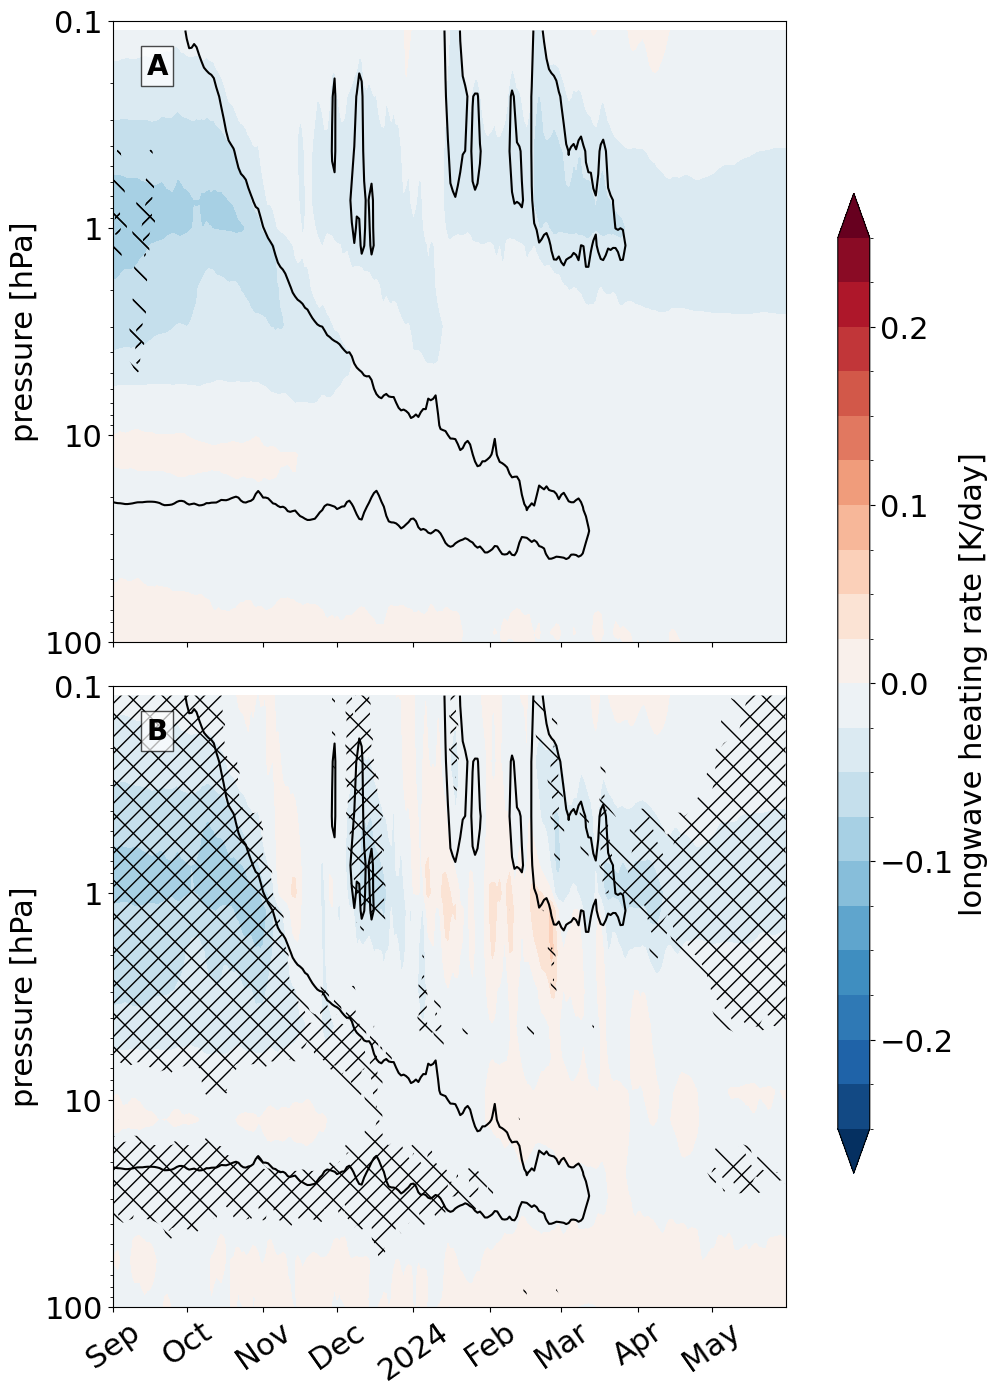

In [15]:
f, axes = plt.subplots(2, 1, figsize=(8, 14), sharex=True)
p_ls = []


weights = np.cos(np.deg2rad(ds_lw.lat))
weights.name = "weights"

ax = axes[0]
ds_lw_sel = ds_lw3.sel(pressure = slice(100,0.09))
arr1 = ds_lw_sel['heating_rate_clearsky'].weighted(weights).mean(['lat']).sel(experiment = 'with')
arr2 = ds_lw_sel['heating_rate_clearsky'].weighted(weights).mean(['lat']).sel(experiment = 'without')
t_stat, p_values = stats.ttest_ind(
    arr1, arr2, equal_var=False
)  # , nan_policy = nan_policy)
diff_sel_pcap_pv = xr.DataArray(p_values, coords=arr1[0].coords)
diff_lw = arr1.mean('ens')-arr2.mean('ens')
p = diff_lw.plot.contourf(yincrease = False, x = 'time', levels = 21, vmax = 0.25, ax = ax, add_colorbar = False, extend = 'both')
p_ls.append(p)

(diff_sel_pcap).plot.contour(
    x = 'time', ax = ax, yincrease = False, 
    levels = [0.5], colors = ['k'],
)


kwargs = dict(
    yincrease= False,
    # colors=("k"),
    add_colorbar=False,
    levels=[0, 0.05],
    colors="none",
    hatches=[
        "//",
        None,
    ],
    ax=ax,
    # linewidths=np.linspace(1, 4, 4),
)

diff_sel_pcap_pv.squeeze().plot.contourf(x="time", **kwargs)
kwargs['levels'] = [0,0.1]
kwargs['hatches'] = ["\\",  None]
diff_sel_pcap_pv.squeeze().plot.contourf(x="time", **kwargs)

ax.set_xlabel('')

"""
ax =axes[2]
ds_lw_sel = ds_lw.sel(pressure = slice(100,0.09))
arr1 = ds_lw_sel['heating_rate_clearsky'].weighted(weights).mean(['lat']).sel(experiment = 'with')
arr2 = ds_lw_sel['heating_rate_clearsky'].weighted(weights).mean(['lat']).sel(experiment = 'without')
t_stat, p_values = stats.ttest_ind(
    arr1, arr2, equal_var=False
)  # , nan_policy = nan_policy)
diff_sel_pcap_pv = xr.DataArray(p_values, coords=arr1[0].coords)
diff_lw = arr1.mean('ens')-arr2.mean('ens')
p = diff_lw.plot.contourf(yincrease = False, x = 'time', levels = 21, vmax = 0.25, ax = ax, add_colorbar = False, extend = 'both')
p_ls.append(p)

(diff_sel_pcap).plot.contour(
    x = 'time', ax = ax, yincrease = False, 
    levels = [0.5], colors = ['k'],
)
"""
kwargs = dict(
    yincrease= False,
    # colors=("k"),
    add_colorbar=False,
    levels=[0, 0.05],
    colors="none",
    hatches=[
        "//",
        None,
    ],
    ax=ax,
    # linewidths=np.linspace(1, 4, 4),
)

diff_sel_pcap_pv.squeeze().plot.contourf(x="time", **kwargs)
kwargs['levels'] = [0,0.1]
kwargs['hatches'] = ["\\",  None]
diff_sel_pcap_pv.squeeze().plot.contourf(x="time", **kwargs)

ax.set_xlabel('')

ax =axes[1]
ds_lw_sel = ds_lw2.sel(pressure = slice(100,0.09))
arr1 = ds_lw_sel['heating_rate_clearsky'].weighted(weights).mean(['lat']).sel(experiment = 'with')
arr2 = ds_lw_sel['heating_rate_clearsky'].weighted(weights).mean(['lat']).sel(experiment = 'without')
t_stat, p_values = stats.ttest_ind(
    arr1, arr2, equal_var=False
)  # , nan_policy = nan_policy)
diff_sel_pcap_pv = xr.DataArray(p_values, coords=arr1[0].coords)

diff_lw = arr1.mean('ens')-arr2.mean('ens')
p2 = diff_lw.plot.contourf(yincrease = False, x = 'time', levels = 21, vmax = 0.25, ax = ax, add_colorbar = False, extend = 'both')
p_ls.append(p2)

(diff_sel_pcap).plot.contour(
    x = 'time', ax = ax, yincrease = False, 
    levels = [0.5], colors = ['k'],
)

kwargs = dict(
    yincrease= False,
    # colors=("k"),
    add_colorbar=False,
    levels=[0, 0.05],
    colors="none",
    hatches=[
        "//",
        None,
    ],
    ax=ax,
    # linewidths=np.linspace(1, 4, 4),
)

diff_sel_pcap_pv.squeeze().plot.contourf(x="time", **kwargs)
kwargs['levels'] = [0,0.1]
kwargs['hatches'] = ["\\",  None]
diff_sel_pcap_pv.squeeze().plot.contourf(x="time", **kwargs)

ax.set_xlabel('')


for i,ax in enumerate(axes):
    ax.set_yscale('log')
    ax.set_yticks([100,10,1,0.1])
    fmt = mpl.ticker.FormatStrFormatter("%g")
    ax.yaxis.set_major_formatter(fmt)
    
    label = ascii_uppercase[i]
    ax.text(
            0.05,
            0.95,
            label,
            transform=ax.transAxes,
            fontsize=20,
            fontweight="bold",
            va="top",
            bbox={"alpha": 0.7, "facecolor": "white"},
        )
    ax.set_title('')


X = ax.xaxis
X.set_major_locator(mdates.MonthLocator())#locator_daily)
#X.set_major_formatter(fmt)
X.set_tick_params(rotation=35)

posn = axes[-1].get_position()
cax = f.add_axes([0.1,-0.1,0.5,0.1])
cx_shift= 0.15
cax.set_position([posn.x0+posn.width+cx_shift, posn.y0+0.05, 0.04, posn.height*2])
f.colorbar(p, cax=cax, orientation='vertical', label='longwave heating rate [K/day]', extend = 'both', spacing = 'proportional', ticks = [-0.2,-0.1,0,0.1,0.2])

plt.tight_layout(pad=0.4, w_pad=0.5, h_pad=.5)


outfile = f"2xHR+WV_time-evolution_2023-2024.pdf"
print(outfile)
plt.savefig(outfile, bbox_inches="tight")

In [16]:
from run_webdav_boku import run_client

client = run_client()
client.exists(f"HT_analysis/figs/strengthening/{outfile}")

True

In [17]:
client.upload_file(outfile, f"HT_analysis/figs/strengthening/{outfile}", overwrite=True)